In [43]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
from scipy.sparse import hstack
from sklearn.metrics import confusion_matrix

### Pre-processing

In [2]:
DATA_PATH = '/home/eliyaah/big_data_proj' 
df = pd.read_csv(os.path.join(DATA_PATH, 'cleaned_news_dataset_w_derived_columns.csv'))

In [3]:
FEATURE_COLUMNS = [
    'exclamation_count_title', 'question_count_title', 'quotes_count_title',
    'ellipsis_count_title', 'hashtag_count_title', 'mention_count_title',
    'noun_ratio_title', 'verb_ratio_title', 'adj_ratio_title',
    'sentiment_polarity_title', 'sentiment_subjectivity_title',
    'capitalization_ratio_title', 'html_link_count_title',
    'exclamation_count_text', 'question_count_text', 'quotes_count_text',
    'ellipsis_count_text', 'hashtag_count_text', 'mention_count_text',
    'noun_ratio_text', 'verb_ratio_text', 'adj_ratio_text',
    'sentiment_polarity_text', 'sentiment_subjectivity_text',
    'capitalization_ratio_text', 'html_link_count_text'
]

In [4]:
def remove_reuters(text):
    if pd.isna(text):
        return ''
    return text.lower().replace('reuters', '').strip()

df['title'] = df['title'].apply(remove_reuters)
df['text'] = df['text'].apply(remove_reuters)

In [5]:
df['text'] = df['text'].str.replace(r'^[A-Z ,./\-a-z]*\s*\(Reuters\)\s*[-–—]*\s*', '', regex=True)

In [6]:
def prepare_text_versions(df):
    df = df.copy()
    df['text_title_only'] = df['title'].fillna('')
    df['text_body_only'] = df['text'].fillna('')
    df['text_combined'] = df['title'].fillna('') + ' [SEP] ' + df['text'].fillna('')
    return df
df = prepare_text_versions(df)

In [7]:
def prepare_data_splits(df, test_size=0.2, val_size=0.2):
    used_features = [col for col in FEATURE_COLUMNS if col in df.columns]
    
    train_val_df, test_df = train_test_split(df, test_size=test_size, stratify=df['label'], random_state=42)
    train_df, val_df = train_test_split(train_val_df, test_size=val_size, stratify=train_val_df['label'], random_state=42)
    
    return train_df, val_df, test_df, used_features

train_df, val_df, test_df, used_features = prepare_data_splits(df)

In [8]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("Features used:", used_features)


Train size: 24574
Validation size: 6144
Test size: 7680
Features used: ['exclamation_count_title', 'question_count_title', 'quotes_count_title', 'ellipsis_count_title', 'hashtag_count_title', 'mention_count_title', 'noun_ratio_title', 'verb_ratio_title', 'adj_ratio_title', 'sentiment_polarity_title', 'sentiment_subjectivity_title', 'capitalization_ratio_title', 'html_link_count_title', 'exclamation_count_text', 'question_count_text', 'quotes_count_text', 'ellipsis_count_text', 'hashtag_count_text', 'mention_count_text', 'noun_ratio_text', 'verb_ratio_text', 'adj_ratio_text', 'sentiment_polarity_text', 'sentiment_subjectivity_text', 'capitalization_ratio_text', 'html_link_count_text']


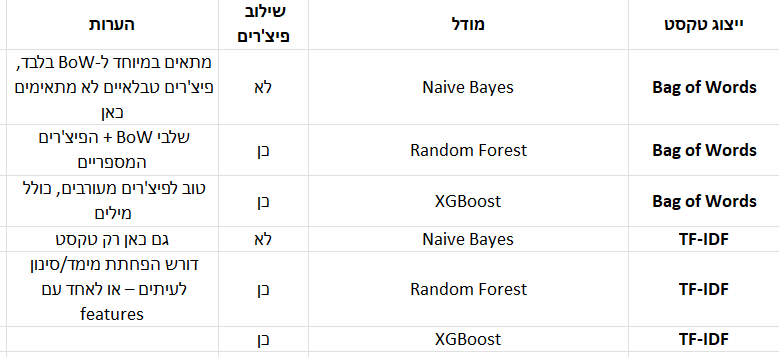

### Naive Bayes: Bag-of-Words and TF-IDF 

Both created using unigram and bigram

In [ ]:
def run_naive_bayes_with_vectorizer(text_column, vectorizer_type='bow'):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('clf', MultinomialNB())
    ])

    pipeline.fit(train_df[text_column], train_df['label'])
    y_pred = pipeline.predict(test_df[text_column])
    y_true = test_df['label']

    # full classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    
    return {
        'Config': f"{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4)
    }

In [24]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
results = []

for col in text_columns:
    results.append(run_naive_bayes_with_vectorizer(col, vectorizer_type='bow'))
    results.append(run_naive_bayes_with_vectorizer(col, vectorizer_type='tfidf'))

results_df = pd.DataFrame(results)

           Config     F1  Precision  Recall  Accuracy
0       BOW_Title  0.930      0.924   0.937     0.937
1     TFIDF_Title  0.928      0.932   0.923     0.936
2        BOW_Body  0.942      0.962   0.922     0.949
3      TFIDF_Body  0.929      0.948   0.912     0.938
4    BOW_Combined  0.959      0.965   0.954     0.964
5  TFIDF_Combined  0.945      0.950   0.940     0.951


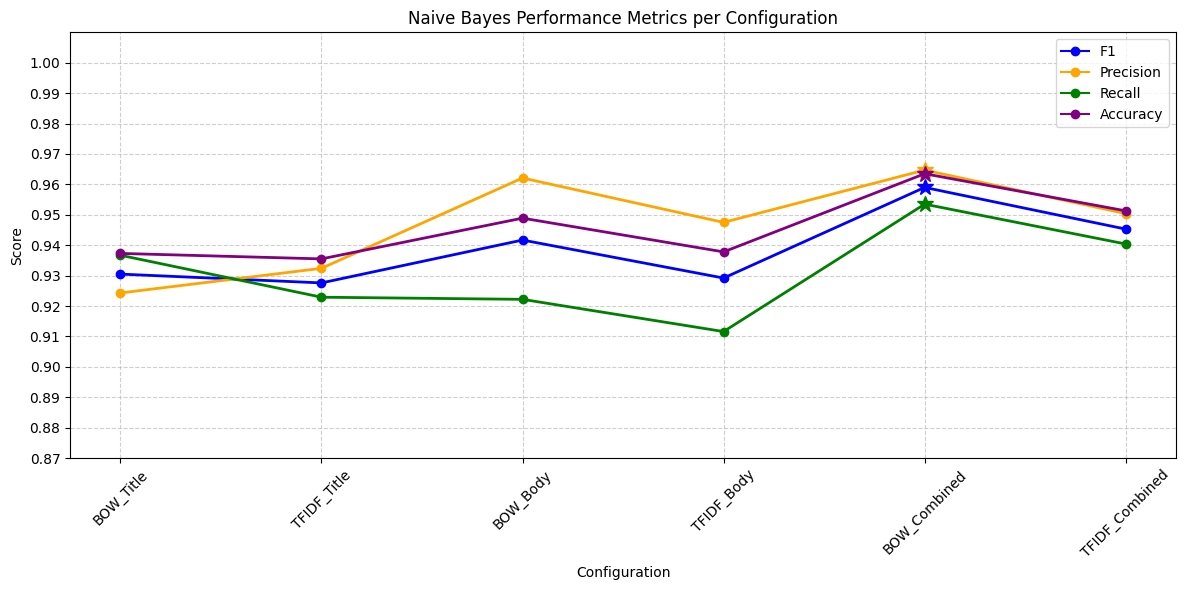

In [39]:
def plot_metrics_comparison_improved(results_df):
    """
    Plots F1, Precision, Recall, and Accuracy for each configuration.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot dots for all points
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric (only once)
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.85, 1.00, 16))
    plt.ylim(0.87, 1.01)

    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("Naive Bayes Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

print(results_df.round(3))
plot_metrics_comparison_improved(results_df)

### Random Forest: Bag-of-Words and TF-IDF (Using Features)

In [43]:
def run_random_forest_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    preprocessor = ColumnTransformer([
        ('text', vectorizer, text_column),
        ('features', StandardScaler(), FEATURE_COLUMNS)
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    pipeline.fit(train_df, train_df['label'])
    y_pred = pipeline.predict(val_df)
    y_true = val_df['label']

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        'Config': f"RF_{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4)
    }
    if return_model:
        return result, pipeline
    else:
        return result

In [44]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
rf_results = []

for col in text_columns:
    rf_results.append(run_random_forest_with_vectorizer(col, vectorizer_type='bow'))
    rf_results.append(run_random_forest_with_vectorizer(col, vectorizer_type='tfidf'))

rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df.to_string(index=False))

           Config     F1  Precision  Recall  Accuracy
     RF_BOW_Title 0.9864     0.9948  0.9782    0.9880
   RF_TFIDF_Title 0.9860     0.9956  0.9767    0.9876
      RF_BOW_Body 0.9980     0.9985  0.9975    0.9982
    RF_TFIDF_Body 0.9982     0.9985  0.9978    0.9984
  RF_BOW_Combined 0.9984     0.9989  0.9978    0.9985
RF_TFIDF_Combined 0.9991     1.0000  0.9982    0.9992


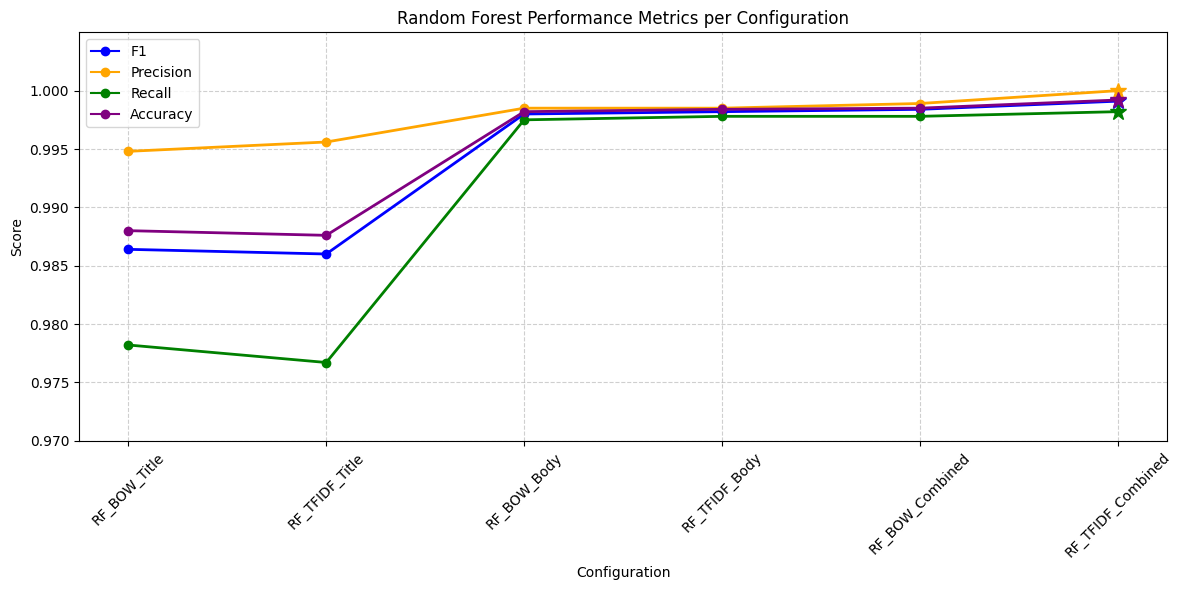

In [45]:
def plot_metrics_comparison_rf(results_df):
    """
    Visualizes F1, Precision, Recall, and Accuracy for Random Forest results.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot individual markers (o or *)
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.97, 1.00, 7))
    plt.ylim(0.97, 1.005)
    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("Random Forest Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_metrics_comparison_rf(rf_results_df)

In [ ]:
# Run again with return_model=True for one configuration (e.g., combined + tfidf) - BEST
_, pipeline = run_random_forest_with_vectorizer('text_combined', vectorizer_type='tfidf', return_model=True)

# Extract text feature count
text_transformer = pipeline.named_steps['preprocess'].transformers_[0][1]
text_column_name = pipeline.named_steps['preprocess'].transformers_[0][2]
text_data = text_transformer.transform(train_df[text_column_name])
text_feature_count = text_data.shape[1]

# Get full importances and extract numeric part
importances = pipeline.named_steps['clf'].feature_importances_
numeric_importances = importances[text_feature_count:]

# Create DataFrame with numeric feature names
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': numeric_importances
}).sort_values(by='Importance', ascending=False)

# Print the result
print("\n=== Numeric Feature Importances (for Combined + TFIDF) ===")
print(importance_df.to_string(index=False))


=== Numeric Feature Importances (for Combined + TFIDF) ===
                     Feature  Importance
  capitalization_ratio_title    0.030195
             adj_ratio_title    0.017184
           quotes_count_text    0.016844
            noun_ratio_title    0.015521
         question_count_text    0.011995
            verb_ratio_title    0.010557
      exclamation_count_text    0.009720
             noun_ratio_text    0.008700
          mention_count_text    0.007629
 sentiment_subjectivity_text    0.006913
     exclamation_count_title    0.005024
             verb_ratio_text    0.004578
          quotes_count_title    0.004563
   capitalization_ratio_text    0.004340
sentiment_subjectivity_title    0.004277
         ellipsis_count_text    0.003576
          hashtag_count_text    0.002733
    sentiment_polarity_title    0.001034
              adj_ratio_text    0.000941
     sentiment_polarity_text    0.000440
        question_count_title    0.000398
         hashtag_count_title    0.0001

### XGBoost: Bag-of-Words and TF-IDF (Using Features)

In [56]:
def clean_feature_name(name):
    if name.startswith("text__"):
        word = name.replace("text__", "")
        return f"'{word}'"
    elif name.startswith("features__"):
        col = name.replace("features__", "")
        col = col.replace("_", " ").capitalize()
        return f"{col}"
    else:
        return name

In [49]:
def run_xgboost_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    preprocessor = ColumnTransformer([
        ('text', vectorizer, text_column),
        ('features', StandardScaler(), FEATURE_COLUMNS)
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])

    pipeline.fit(train_df, train_df['label'])
    y_pred = pipeline.predict(val_df)
    y_true = val_df['label']

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        'Config': f"XGB_{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4)
    }

    if return_model:
        return result, pipeline
    else:
        return result

In [50]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
xgb_results = []

for col in text_columns:
    xgb_results.append(run_xgboost_with_vectorizer(col, vectorizer_type='bow'))
    xgb_results.append(run_xgboost_with_vectorizer(col, vectorizer_type='tfidf'))

xgb_results_df = pd.DataFrame(xgb_results)
print(xgb_results_df.to_string(index=False))

/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:33:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:34:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:35:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:35:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

            Config     F1  Precision  Recall  Accuracy
     XGB_BOW_Title 0.9878     0.9905  0.9851    0.9891
   XGB_TFIDF_Title 0.9860     0.9894  0.9825    0.9875
      XGB_BOW_Body 0.9976     0.9985  0.9967    0.9979
    XGB_TFIDF_Body 0.9975     0.9985  0.9964    0.9977
  XGB_BOW_Combined 0.9978     0.9985  0.9971    0.9980
XGB_TFIDF_Combined 0.9978     0.9985  0.9971    0.9980


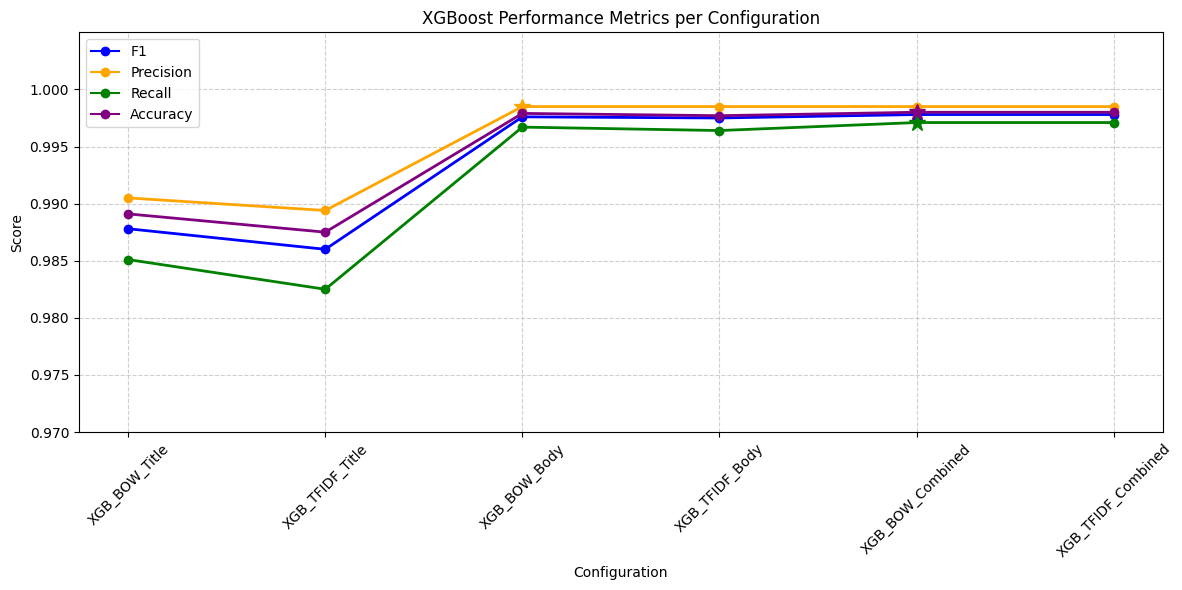

In [52]:
def plot_metrics_comparison_xgb(results_df):
    """
    Visualizes F1, Precision, Recall, and Accuracy for XGBoost results.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot individual markers (o or *)
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.97, 1.00, 7))
    plt.ylim(0.97, 1.005)
    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("XGBoost Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_metrics_comparison_xgb(xgb_results_df)

In [59]:
xgb_result, model = run_xgboost_with_vectorizer(
    text_column='text_combined',
    vectorizer_type='bow',
    return_model=True
)
vectorizer = model.named_steps['preprocess'].transformers_[0][1]
numeric_features = FEATURE_COLUMNS
text_features = vectorizer.get_feature_names_out()
full_feature_names = [f"text__{word}" for word in text_features] + [f"features__{f}" for f in numeric_features]
importances = model.named_steps['clf'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': full_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp_df['ReadableFeature'] = feat_imp_df['Feature'].apply(clean_feature_name)

# Show top 20
top_20 = feat_imp_df.head(20)
print(top_20)

/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:58:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                                    Feature  Importance  \
6737                          text__reuters    0.760854   
2854                   text__featured image    0.022521   
1520                     text__century wire    0.011288   
9370                        text__video sep    0.008290   
5370                 text__nov presidential    0.007271   
2792                          text__factbox    0.007225   
6443                        text__read more    0.006690   
4820                 text__mainstream media    0.006003   
10000     features__exclamation_count_title    0.005451   
10011  features__capitalization_ratio_title    0.004905   
9349                              text__via    0.004742   
10017          features__hashtag_count_text    0.004165   
2382                         text__document    0.004015   
2936                            text__first    0.003419   
1988                           text__course    0.002825   
3816                            text__image    0.002799 

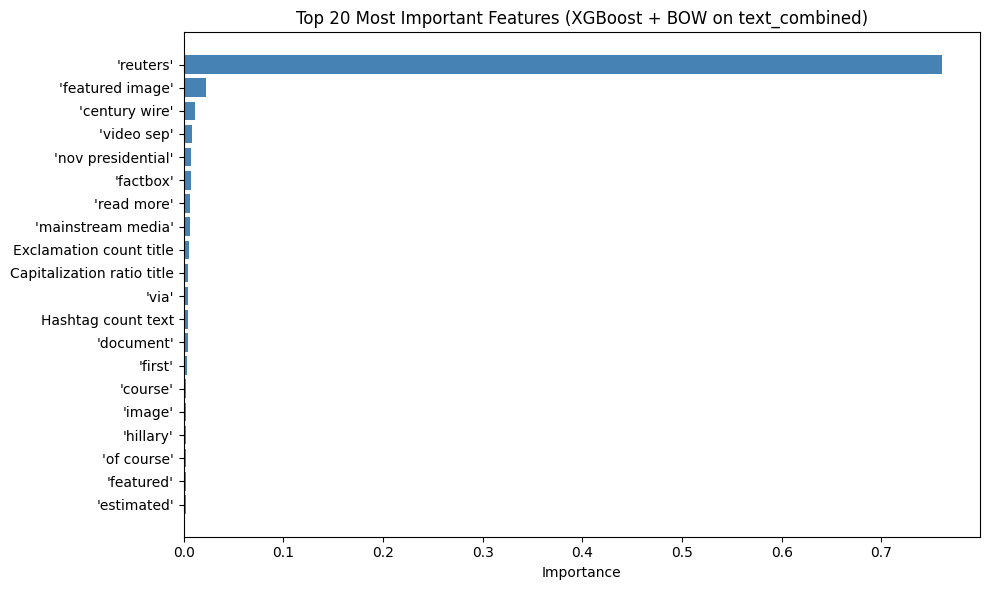

In [60]:
# Plot top 20 features
plt.figure(figsize=(10, 6))
plt.barh(top_20['ReadableFeature'][::-1], top_20['Importance'][::-1], color='steelblue')
plt.xlabel("Importance")
plt.title("Top 20 Most Important Features (XGBoost + BOW on text_combined)")
plt.tight_layout()
plt.show()

**AT THIS POINT WE RELEASED WE HAVE A PROBLEM!**

In [63]:
df['contains_reuters_title'] = df['title'].fillna('').str.lower().str.contains('reuters')
print("🔍 Appearance in TITLE:")
print(df.groupby('label')['contains_reuters_title'].mean())

🔍 Appearance in TITLE:
label
0    0.006365
1    0.000175
Name: contains_reuters_title, dtype: float64


In [64]:
df['contains_reuters_text'] = df['text'].fillna('').str.lower().str.contains('reuters')
print("\n🔍 Appearance in TEXT:")
print(df.groupby('label')['contains_reuters_text'].mean())


🔍 Appearance in TEXT:
label
0    0.998161
1    0.012102
Name: contains_reuters_text, dtype: float64


### NOW WITHOUT Reuters

### Naive Bayes: Bag-of-Words and TF-IDF 

We trained a Multinomial Naive Bayes model using n-gram text features to classify news as real or fake, serving as a lightweight baseline for comparison

In [44]:
def run_naive_bayes_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('clf', MultinomialNB())
    ])

    pipeline.fit(train_df[text_column], train_df['label'])
    y_pred = pipeline.predict(test_df[text_column])
    y_true = test_df['label']

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    # full classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    
    result = {
        'Config': f"{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'FPR': round(fpr, 4)
    }

    if return_model:
        return result, pipeline
    else:
        return result

In [45]:
def plot_metrics_comparison_improved(results_df):
    """
    Plots F1, Precision, Recall, and Accuracy for each configuration.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot dots for all points
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric (only once)
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.85, 1.00, 10))
    plt.ylim(0.87, 1.01)

    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("Naive Bayes Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [46]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
results = []

for col in text_columns:
    results.append(run_naive_bayes_with_vectorizer(col, vectorizer_type='bow'))
    results.append(run_naive_bayes_with_vectorizer(col, vectorizer_type='tfidf'))

results_df = pd.DataFrame(results)

           Config     F1  Precision  Recall  Accuracy    FPR
0       BOW_Title  0.936      0.924   0.950     0.942  0.064
1     TFIDF_Title  0.933      0.930   0.935     0.940  0.057
2        BOW_Body  0.936      0.950   0.921     0.943  0.039
3      TFIDF_Body  0.924      0.937   0.912     0.933  0.050
4    BOW_Combined  0.955      0.954   0.956     0.960  0.037
5  TFIDF_Combined  0.944      0.944   0.943     0.950  0.045


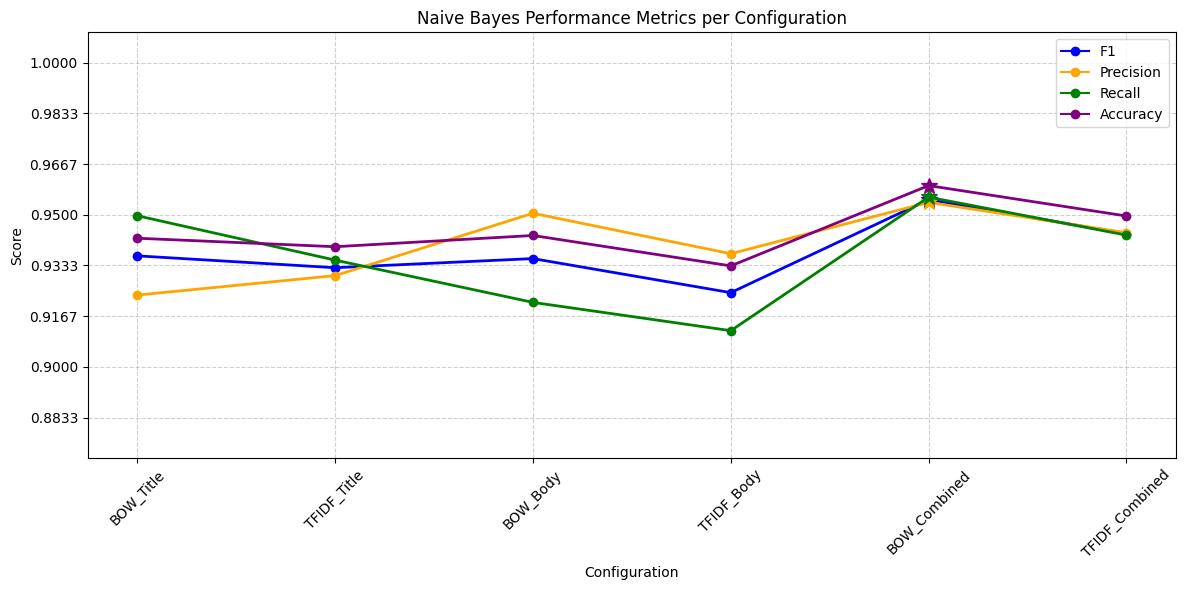

In [47]:
print(results_df.round(3))
plot_metrics_comparison_improved(results_df)

In [20]:
def get_top_features_naive_bayes(model, top_k=20):
    vectorizer = model.named_steps['vectorizer']
    clf = model.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()

    importance = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]

    top_fake_indices = np.argsort(importance)[::-1][:top_k]
    top_fake = pd.DataFrame({
        'Feature': [feature_names[i] for i in top_fake_indices],
        'Score': [importance[i] for i in top_fake_indices],
        'Label': ['Fake (1)'] * top_k
    })

    top_real_indices = np.argsort(importance)[:top_k]
    top_real = pd.DataFrame({
        'Feature': [feature_names[i] for i in top_real_indices],
        'Score': [importance[i] for i in top_real_indices],
        'Label': ['Real (0)'] * top_k
    })

    return pd.concat([top_fake, top_real], ignore_index=True)

In [21]:
_, nb_model = run_naive_bayes_with_vectorizer('text_combined', vectorizer_type='bow', return_model=True)
top_features_df = get_top_features_naive_bayes(nb_model)
print(top_features_df)

                 Feature     Score     Label
0         featured image  8.619962  Fake (1)
1              image via  8.422104  Fake (1)
2            twitter com  8.221071  Fake (1)
3            pic twitter  8.170682  Fake (1)
4           getty images  7.974702  Fake (1)
5                  https  7.810216  Fake (1)
6               https co  7.506190  Fake (1)
7                  getty  7.309453  Fake (1)
8              video sep  7.163379  Fake (1)
9         screen capture  6.905896  Fake (1)
10                   pic  6.812729  Fake (1)
11                21wire  6.775303  Fake (1)
12  2017 realdonaldtrump  6.768762  Fake (1)
13          century wire  6.646046  Fake (1)
14                  quot  6.501003  Fake (1)
15                    js  6.464318  Fake (1)
16           via youtube  6.250913  Fake (1)
17             via getty  6.237609  Fake (1)
18        below featured  6.114230  Fake (1)
19                flickr  6.049018  Fake (1)
20              rohingya -7.159521  Real (0)
21        

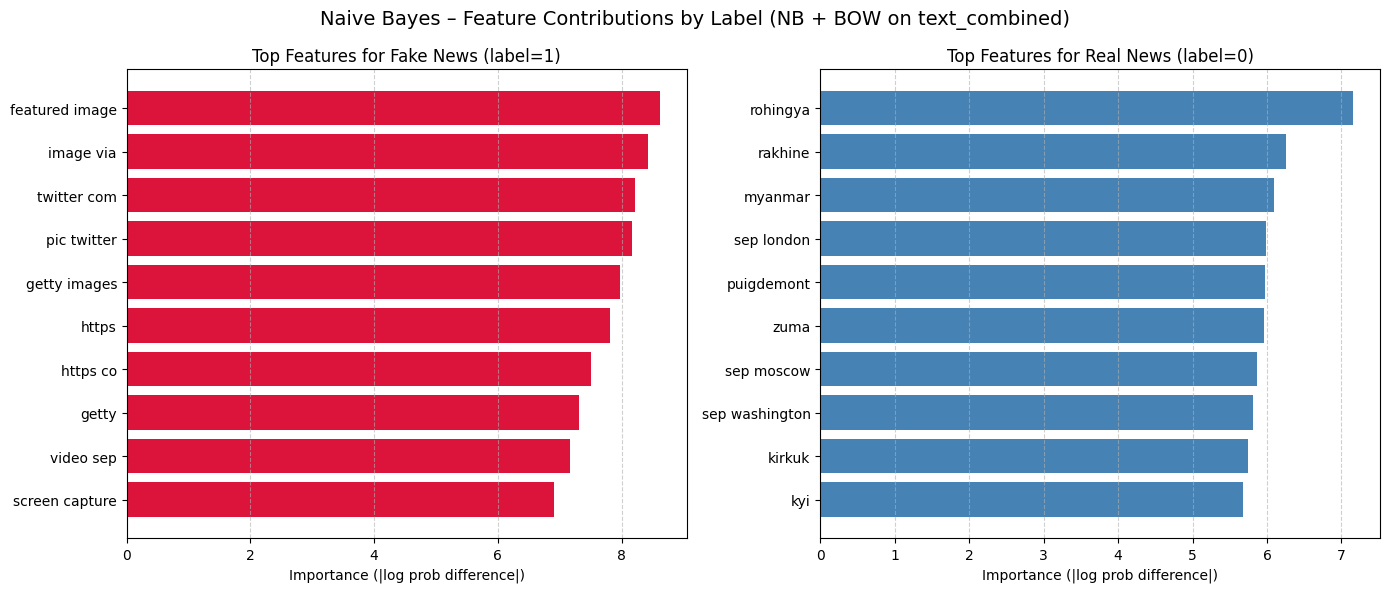

In [22]:
def plot_top_features_naive_bayes_dual(top_features_df, config_label="NB + BOW on text_combined"):
    top_features_df['AbsScore'] = top_features_df['Score'].abs()
    fake_df = top_features_df[top_features_df['Label'] == 'Fake (1)'].head(10)
    real_df = top_features_df[top_features_df['Label'] == 'Real (0)'].head(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Fake news plot
    axes[0].barh(fake_df['Feature'][::-1], fake_df['AbsScore'][::-1], color='crimson')
    axes[0].set_title("Top Features for Fake News (label=1)")
    axes[0].set_xlabel("Importance (|log prob difference|)")
    axes[0].grid(True, axis='x', linestyle='--', alpha=0.6)

    # Real news plot
    axes[1].barh(real_df['Feature'][::-1], real_df['AbsScore'][::-1], color='steelblue')
    axes[1].set_title("Top Features for Real News (label=0)")
    axes[1].set_xlabel("Importance (|log prob difference|)")
    axes[1].grid(True, axis='x', linestyle='--', alpha=0.6)

    fig.suptitle(f"Naive Bayes – Feature Contributions by Label ({config_label})", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_top_features_naive_bayes_dual(top_features_df)

All features are textual n-grams that created authomatically by the CountVectorizer

### Random Forest: Bag-of-Words and TF-IDF (Using Features)

In [48]:
def run_random_forest_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    preprocessor = ColumnTransformer([
        ('text', vectorizer, text_column),
        ('features', StandardScaler(), FEATURE_COLUMNS)
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    pipeline.fit(train_df, train_df['label'])
    y_pred = pipeline.predict(test_df)
    y_true = test_df['label']

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        'Config': f"RF_{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'FPR': round(fpr, 4)
    }
    if return_model:
        return result, pipeline
    else:
        return result

In [49]:
def plot_metrics_comparison_rf(results_df):
    """
    Visualizes F1, Precision, Recall, and Accuracy for Random Forest results.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot individual markers (o or *)
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.97, 1.00, 7))
    plt.ylim(0.97, 1.005)
    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("Random Forest Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [50]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
rf_results = []

for col in text_columns:
    rf_results.append(run_random_forest_with_vectorizer(col, vectorizer_type='bow'))
    rf_results.append(run_random_forest_with_vectorizer(col, vectorizer_type='tfidf'))

rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df.to_string(index=False))

           Config     F1  Precision  Recall  Accuracy    FPR
     RF_BOW_Title 0.9843     0.9914  0.9773    0.9861 0.0068
   RF_TFIDF_Title 0.9852     0.9950  0.9756    0.9868 0.0040
      RF_BOW_Body 0.9936     0.9985  0.9887    0.9943 0.0012
    RF_TFIDF_Body 0.9945     0.9979  0.9910    0.9951 0.0017
  RF_BOW_Combined 0.9946     0.9977  0.9916    0.9952 0.0019
RF_TFIDF_Combined 0.9948     0.9974  0.9921    0.9953 0.0021


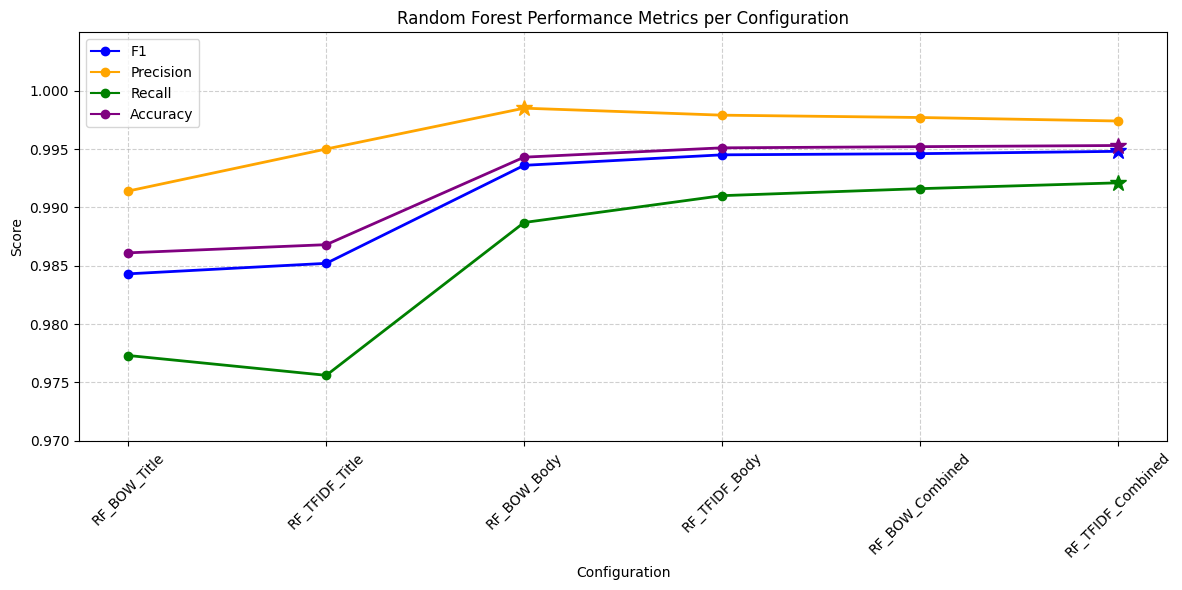

In [32]:
plot_metrics_comparison_rf(rf_results_df)

In [39]:
_, rf_pipeline = run_random_forest_with_vectorizer('text_combined', vectorizer_type='tfidf', return_model=True)

vectorizer = rf_pipeline.named_steps['preprocess'].transformers_[0][1]
text_column = rf_pipeline.named_steps['preprocess'].transformers_[0][2]
scaler = rf_pipeline.named_steps['preprocess'].transformers_[1][1]
clf = rf_pipeline.named_steps['clf']

X_text = vectorizer.transform(train_df[text_column])
X_num = scaler.transform(train_df[FEATURE_COLUMNS])
X_all = hstack([X_text, X_num]).toarray()

text_features = [f"text__{f}" for f in vectorizer.get_feature_names_out()]
num_features = [f"feat__{col}" for col in FEATURE_COLUMNS]
all_features = text_features + num_features

def clean_feature_name(name):
    if name.startswith("text__"):
        return name.replace("text__", "").replace("_", " ")
    elif name.startswith("feat__"):
        return name.replace("feat__", "").replace("_", " ")
    return name

clean_names = [clean_feature_name(name) for name in all_features]

explainer = shap.Explainer(clf, X_all)
shap_values = explainer(X_all)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-15:][::-1]
top_features = [clean_names[i] for i in top_indices]
top_values = mean_abs_shap[top_indices]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_features)), top_values[::-1], color="mediumseagreen")
plt.yticks(range(len(top_features)), top_features[::-1], fontsize=10)
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.title("Top 15 SHAP Features for Random Forest\n(text_combined + TFIDF)", fontsize=14)
plt.tight_layout()
plt.show()


100%|===================| 49119/49148 [19:24<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.840000, while the model output was 0.870000. If this difference is acceptable you can set check_additivity=False to disable this check.

### XGBoost: Bag-of-Words and TF-IDF (Using Features)

In [9]:
def clean_feature_name(name):
    if name.startswith("text__"):
        word = name.replace("text__", "")
        return f"'{word}'"
    elif name.startswith("features__"):
        col = name.replace("features__", "")
        col = col.replace("_", " ").capitalize()
        return f"{col}"
    else:
        return name

In [10]:
def run_xgboost_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    preprocessor = ColumnTransformer([
        ('text', vectorizer, text_column),
        ('features', StandardScaler(), FEATURE_COLUMNS)
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])

    pipeline.fit(train_df, train_df['label'])
    y_pred = pipeline.predict(test_df)
    y_true = test_df['label']

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        'Config': f"XGB_{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4)
    }

    if return_model:
        return result, pipeline
    else:
        return result

In [23]:
def plot_metrics_comparison_xgb(results_df):
    """
    Visualizes F1, Precision, Recall, and Accuracy for XGBoost results.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot individual markers (o or *)
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'])
    plt.yticks(np.linspace(0.97, 1.00, 7))
    plt.ylim(0.97, 1.005)
    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("XGBoost Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [24]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
xgb_results = []

for col in text_columns:
    xgb_results.append(run_xgboost_with_vectorizer(col, vectorizer_type='bow'))
    xgb_results.append(run_xgboost_with_vectorizer(col, vectorizer_type='tfidf'))

xgb_results_df = pd.DataFrame(xgb_results)
print(xgb_results_df.to_string(index=False))

/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:16:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:16:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:17:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:18:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

            Config     F1  Precision  Recall  Accuracy
     XGB_BOW_Title 0.9872     0.9892  0.9852    0.9885
   XGB_TFIDF_Title 0.9864     0.9889  0.9840    0.9879
      XGB_BOW_Body 0.9983     0.9983  0.9983    0.9984
    XGB_TFIDF_Body 0.9981     0.9983  0.9980    0.9983
  XGB_BOW_Combined 0.9991     0.9985  0.9997    0.9992
XGB_TFIDF_Combined 0.9980     0.9977  0.9983    0.9982


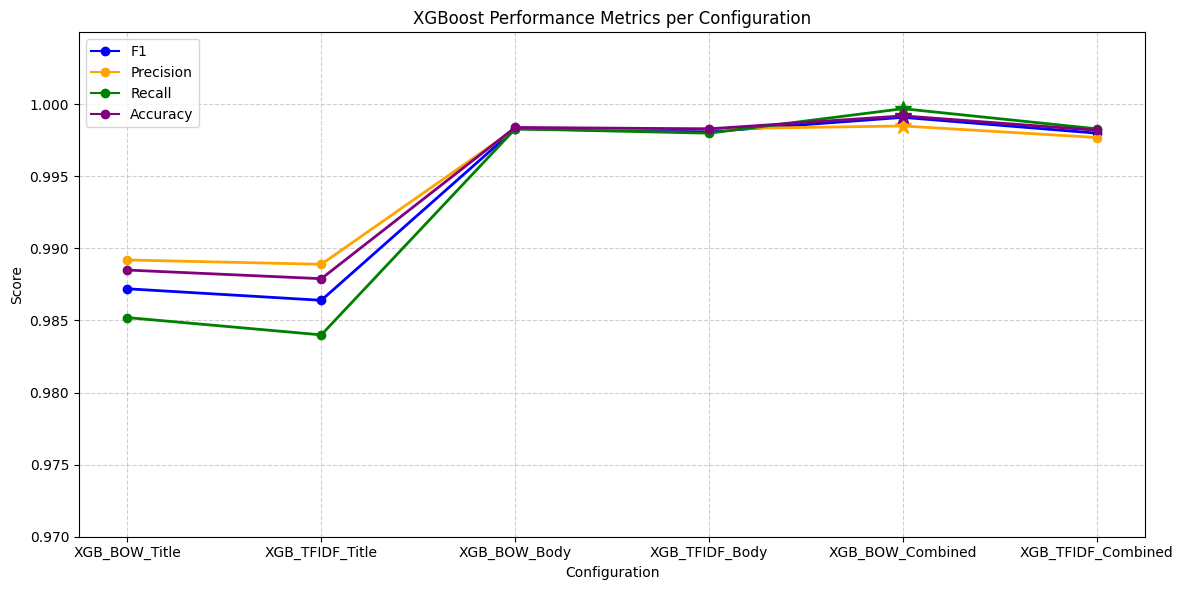

In [25]:
plot_metrics_comparison_xgb(xgb_results_df)

In [ ]:
import textwrap

def wrap_feature_name(name, width=20):
    return "\n".join(textwrap.wrap(name, width=width))


/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:43:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 99%|===================| 24326/24574 [01:22<00:00]        

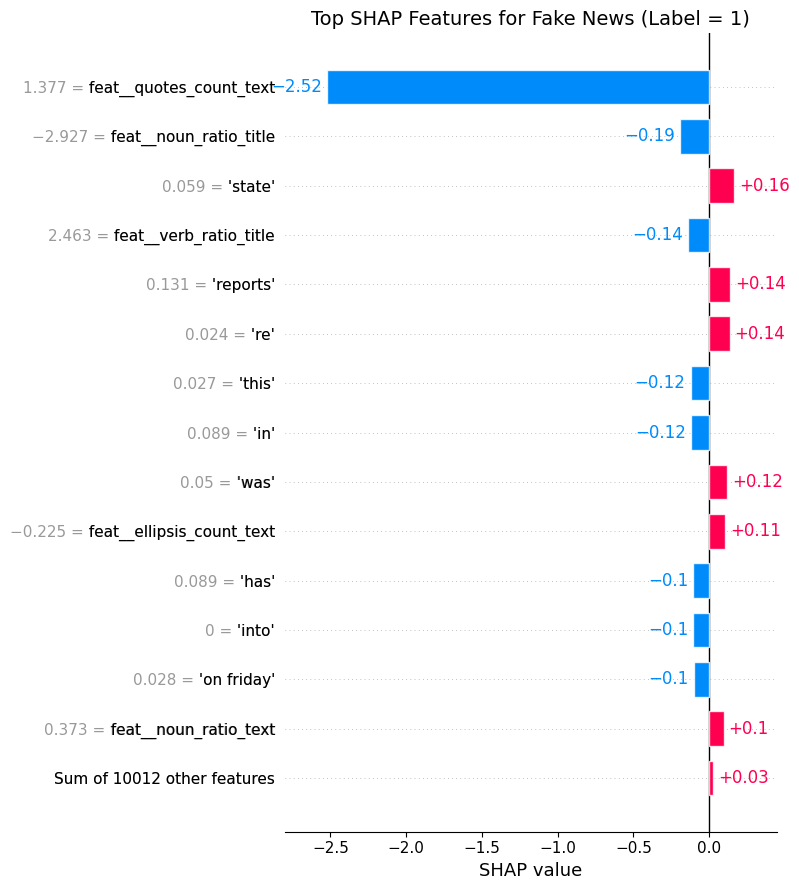

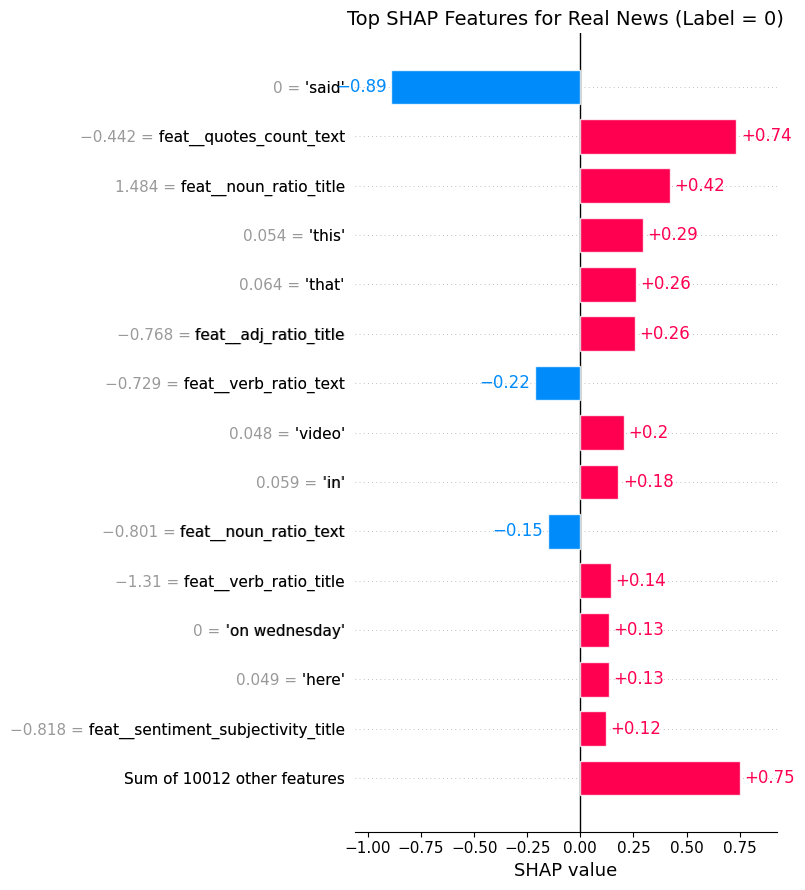

In [28]:
_, pipeline = run_xgboost_with_vectorizer('text_combined', vectorizer_type='tfidf', return_model=True)

vectorizer = pipeline.named_steps['preprocess'].transformers_[0][1]
text_column = pipeline.named_steps['preprocess'].transformers_[0][2]
scaler = pipeline.named_steps['preprocess'].transformers_[1][1]
clf = pipeline.named_steps['clf']

X_text_sparse = vectorizer.transform(train_df[text_column])
X_num = scaler.transform(train_df[FEATURE_COLUMNS])
X_all_sparse = hstack([X_text_sparse, X_num])
X_all_dense = X_all_sparse.toarray()

text_features = [f"text__{f}" for f in vectorizer.get_feature_names_out()]
num_features = [f"feat__{col}" for col in FEATURE_COLUMNS]
full_feature_names = text_features + num_features

clean_names = [clean_feature_name(name) for name in full_feature_names]
# explainer = shap.Explainer(clf)
explainer = shap.Explainer(clf, X_all_dense, feature_names=clean_names)

shap_values = explainer(X_all_dense)

shap.plots.bar(shap_values[1], max_display=15, show=False)
plt.title("Top SHAP Features for Fake News (Label = 1)", fontsize=14)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

shap.plots.bar(shap_values[0], max_display=15, show=False)
plt.title("Top SHAP Features for Real News (Label = 0)", fontsize=14)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()